In [27]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from tools import *
from scipy.interpolate import interp1d
from statsmodels.nonparametric.kernel_regression import KernelReg
from tools import *

In [29]:
df = pd.read_csv('/Users/kellyhui/Downloads/KH_RBG_PF4_P0_6.csv')
df = clean_and_transpose(df, 31, 129).dropna()

array([[3.51758794, 3.51758794, 5.73366834, 4.71356784, 5.9798995 ,
        3.51758794, 1.26633166]])

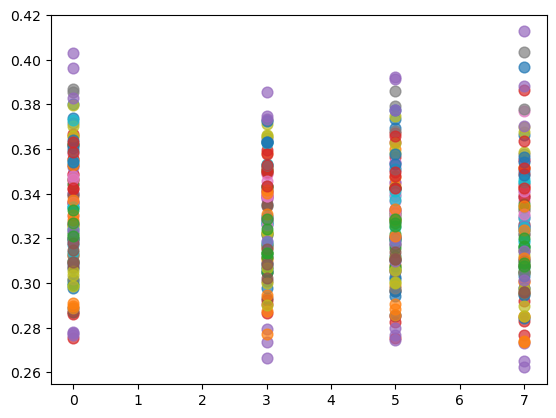

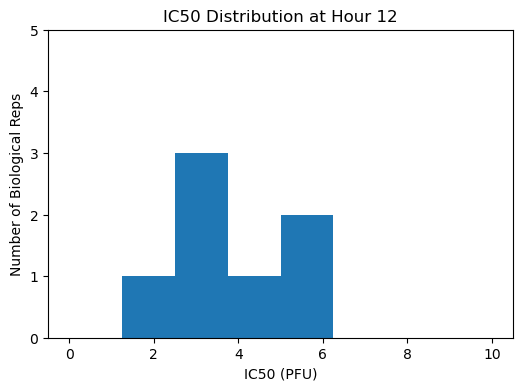

In [33]:
df.index = np.round(df.index).astype(int)
df_hourly = df.loc[df.index.isin(range(0, 16))]
df_hourly = df_hourly.groupby(df_hourly.index).first()

x_vals = [0, 3, 5, 7]
bio_reps = list(string.ascii_uppercase)[:7] #A-H

ic50_table = pd.DataFrame(index=range(8,13), columns=bio_reps, dtype=float)

for hour in range(8, 13):
    if hour not in df_hourly.index:
        continue

    for letter in bio_reps:
        table = df_hourly.filter(regex = rf'^{letter}')
        if table.empty:
            continue
            
        y_vals = table.loc[hour].values
        
        
        x_repeat = np.repeat(x_vals, 3)
            
        plt.scatter(x_repeat, y_vals, label=letter, s=60, alpha=0.7)
        
       # Fit kernel regression
        kr = KernelReg(endog=y_vals, exog=x_repeat, var_type='c', reg_type='ll')
        
        # Smooth prediction
        x_grid = np.linspace(min(x_repeat), max(x_repeat), 200)
        y_pred_grid, _ = kr.fit(x_grid)
        
        # Half-max from smooth curve
        half_max = (y_pred_grid.max() + y_pred_grid.min()) / 2
        
        # Find IC50
        idx = np.argmin(np.abs(y_pred_grid - half_max))
        ic50 = x_grid[idx]
        
        # Store in table
        ic50_table.loc[hour, letter] = ic50

        

    
for hour in range(12,13):
    ic50_values = ic50_table.loc[hour].values
    plt.figure(figsize=(6,4))
    plt.hist(ic50_values, bins = 8, range = (0, 10))
    plt.ylim(0, 5) 
    plt.xlabel('IC50 (PFU)')
    plt.ylabel('Number of Biological Reps')
    plt.title(f'IC50 Distribution at Hour {hour}')

np.array(ic50_table.iloc[[4]])

<Figure size 800x500 with 0 Axes>

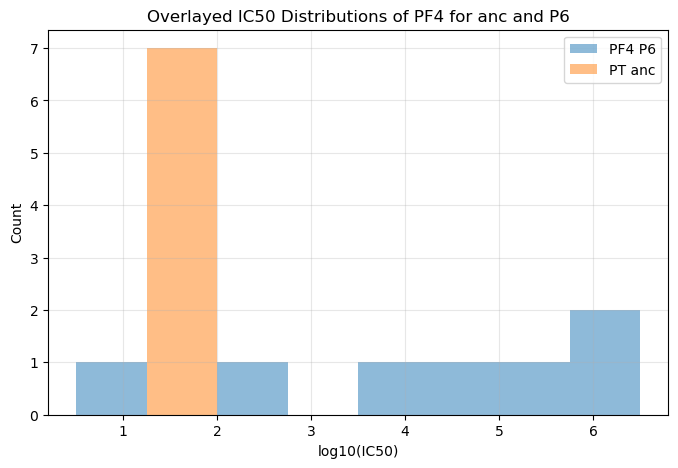

In [61]:


PF4_P6_IC50s = [4.54930059, 5.87557745, 4.21963782, 6.43909788, 2.24729157, 5.50724456, 0.94989606]
#PF4_P0_IC50s = [3.51758794, 3.51758794, 5.73366834, 4.71356784, 5.9798995, 3.51758794, 1.26633166]
PT23_anc_IC50s = [1.93467337, 1.79396985, 1.89949749, 1.93467337, 1.89949749, 1.79396985, 1.79396985]


plt.figure(figsize=(8,5))
plt.figure(figsize=(8,5))

plt.hist(PF4_P6_IC50s, bins=8, alpha=0.5, label='PF4 P6', range=(0.5,6.5))
#plt.hist(PF4_P0_IC50s, bins=12, alpha=0.5, label='PF4 P0', range=(0.5,6.5))
plt.hist(PT23_anc_IC50s, bins=8, alpha=0.5, label='PT anc', range=(0.5,6.5))


plt.xlabel('log10(IC50)')
plt.ylabel('Count')
plt.title('Overlayed IC50 Distributions of PF4 for anc and P6')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

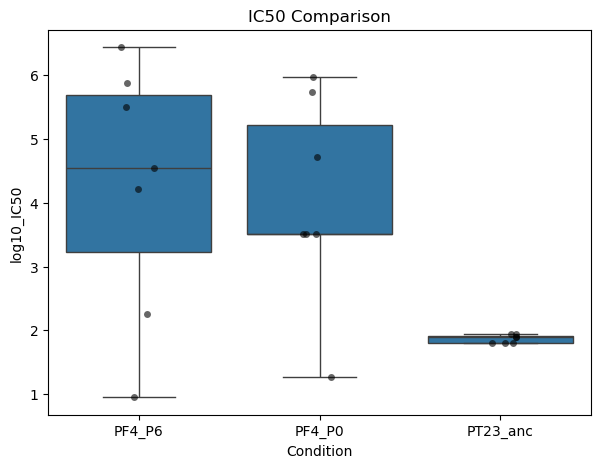

In [46]:
import pandas as pd
import seaborn as sns

df_plot = pd.DataFrame({
    "PF4_P6": PF4_P6_IC50s,
    "PF4_P0": PF4_P0_IC50s,
    "PT23_anc": PT23_anc_IC50s
})

df_melt = df_plot.melt(var_name="Condition", value_name="log10_IC50")

plt.figure(figsize=(7,5))
sns.boxplot(data=df_melt, x="Condition", y="log10_IC50")
sns.stripplot(data=df_melt, x="Condition", y="log10_IC50", color="black", alpha=0.6)

plt.title("IC50 Comparison")
plt.show()